Using device: cpu
Random seed set to: 1234
Loaded model from: TC_01_FIGURES/meta_poisson_model.pt

=== Test case 1/4: center_in_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.070)


/tmp/ipykernel_20178/3501152074.py:616: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)


  Predictor rel L2 = 2.008e-02
  Corrector rel L2 = 7.032e-04 | n_hidden = 304

=== Test case 2/4: off_center_in_range ===
  (x0, y0, nu) = (0.450, 0.550, 0.090)
  Predictor rel L2 = 1.195e-02
  Corrector rel L2 = 5.596e-04 | n_hidden = 304

=== Test case 3/4: shifted_out_of_range ===
  (x0, y0, nu) = (0.300, 0.300, 0.060)
  Predictor rel L2 = 3.569e-01
  Corrector rel L2 = 1.122e-03 | n_hidden = 303

=== Test case 4/4: narrow_out_of_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.030)
  Predictor rel L2 = 3.869e-02
  Corrector rel L2 = 1.656e-03 | n_hidden = 303

[Saved standardized bundle] TC_01_FIGURES/kapi_poisson_corrector_bundle.npz

Saved solution comparison figure to: figures/FIG_TC_01_A_SOLUTION.png
Saved solution comparison figure to: figures/FIG_TC_01_A_SOLUTION.pdf


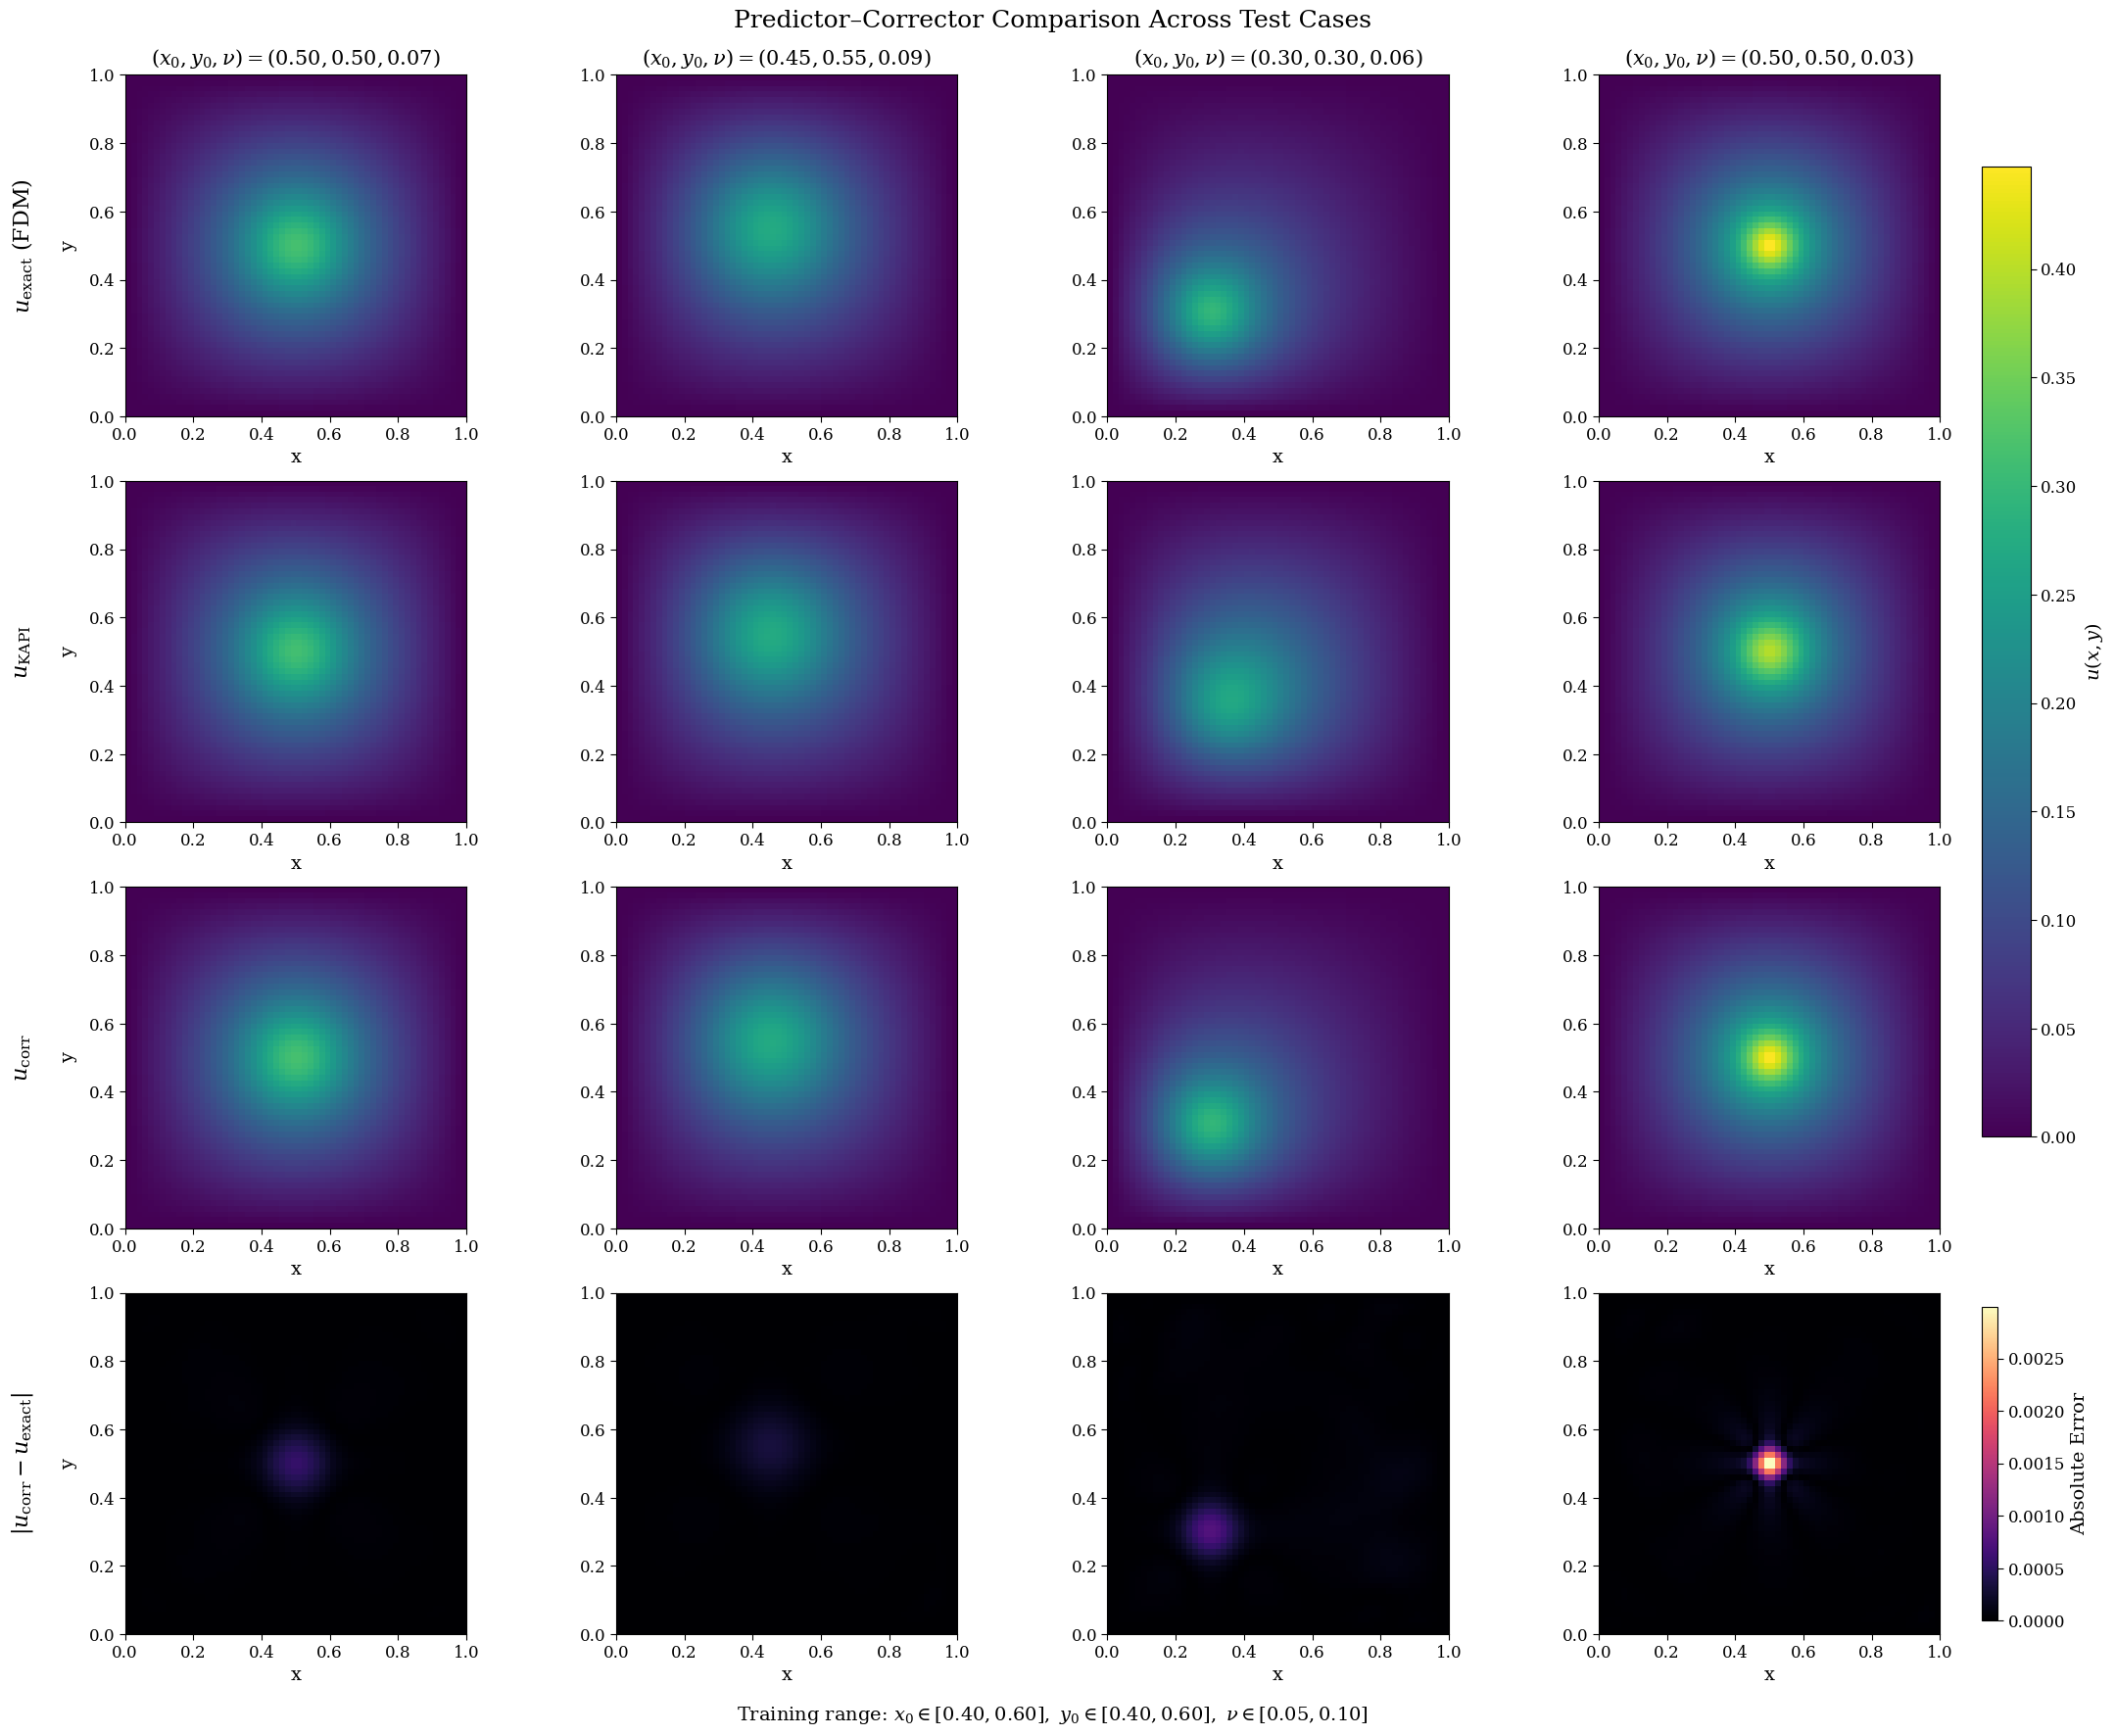


Summary of relative L2 errors:
  center_in_range          : pred=2.008e-02 | corr=7.032e-04 | n_hidden=304
  off_center_in_range      : pred=1.195e-02 | corr=5.596e-04 | n_hidden=304
  shifted_out_of_range     : pred=3.569e-01 | corr=1.122e-03 | n_hidden=303
  narrow_out_of_range      : pred=3.869e-02 | corr=1.656e-03 | n_hidden=303


In [1]:
"""
2D Poisson with Gaussian source:
    -Δu = f(x,y; x0, y0, nu)  on [0,1]^2,  u = 0 on boundary.

POST-PROCESSING STAGE ONLY
--------------------------
This file loads the already-trained meta-conditioned KAPI RBF PINN, evaluates
the four test cases, applies the predictor-guided corrector, computes errors,
and generates plots/data without retraining.
"""

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Publication-quality plotting style
# ------------------------------------------------------------
def set_publication_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 14,
        "axes.titlesize": 15,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.titlesize": 18,
        "mathtext.fontset": "dejavuserif",
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 4.0,
        "ytick.major.size": 4.0,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

DATA_DIR = "TC_01_FIGURES"
os.makedirs(DATA_DIR, exist_ok=True)

MODEL_PATH = "TC_01_FIGURES/meta_poisson_model.pt"

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print("Random seed set to:", SEED)

# ------------------------------------------------------------
# 2D Gaussian source term for Poisson
# f(x,y) = (1/(2πν^2)) exp(-r^2/(2ν^2))
# ------------------------------------------------------------
def gaussian_source_np(x, y, x0, y0, nu):
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return (1.0 / (2.0 * np.pi * nu ** 2)) * np.exp(-r2 / (2.0 * nu ** 2))


# ------------------------------------------------------------
# KAPI-RBF PINN model (meta-conditioned on PDE parameters)
# ------------------------------------------------------------
class KAPIRBF_PINN(nn.Module):
    def __init__(self, M=128, hidden_meta=64):
        super().__init__()
        self.M = M
        self.meta = nn.Sequential(
            nn.Linear(3, hidden_meta),
            nn.Tanh(),
            nn.Linear(hidden_meta, hidden_meta),
            nn.Tanh(),
            nn.Linear(hidden_meta, 4 * M),
        )
        self.c = nn.Parameter(1e-2 * torch.randn(M))

    def _forward_raw(self, p, xy):
        assert p.shape[0] == 1, "This implementation assumes a single p per call."

        p_mean = p.new_tensor([0.5, 0.5, 0.075])
        p_std  = p.new_tensor([0.1, 0.1, 0.025])
        p_norm = (p - p_mean) / p_std

        meta_out = self.meta(p_norm).view(1, 4, self.M)
        g_logits   = meta_out[:, 0, :]
        mu_raw_x   = meta_out[:, 1, :]
        mu_raw_y   = meta_out[:, 2, :]
        log_sigraw = meta_out[:, 3, :]

        g = torch.sigmoid(g_logits).view(self.M)
        mu_x = torch.sigmoid(mu_raw_x).view(self.M)
        mu_y = torch.sigmoid(mu_raw_y).view(self.M)
        sigma = torch.nn.functional.softplus(log_sigraw).view(self.M) + 5e-4

        x = xy[:, 0:1]
        y = xy[:, 1:2]
        x_diff = x - mu_x.view(1, self.M)
        y_diff = y - mu_y.view(1, self.M)
        r2 = (x_diff ** 2 + y_diff ** 2) / (sigma.view(1, self.M) ** 2)
        Phi = torch.exp(-r2)

        coeff = g * self.c
        u_raw = Phi @ coeff
        return u_raw, (g, mu_x, mu_y, sigma)

    def forward(self, p, xy):
        u_raw, aux = self._forward_raw(p, xy)
        x, y = xy[:, 0:1], xy[:, 1:2]
        bc_factor = x * (1.0 - x) * y * (1.0 - y)
        u = u_raw * bc_factor.view(-1)
        return u, aux


# ------------------------------------------------------------
# p-dependent collocation points on [0,1]^2
# ------------------------------------------------------------
def sample_collocation_points_p_dependent(
    N_int,
    N_bc,
    p,
    alpha=None,
    sigma_factor=3.0,
    device=device
):
    x0, y0, nu = p[0]
    if alpha is None:
        alpha = 0.9 if nu.item() < 0.06 else 0.7

    N_loc = int(alpha * N_int)
    N_uni = N_int - N_loc

    if N_loc > 0:
        loc_x = x0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_y = y0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_x = loc_x.clamp(0.0, 1.0)
        loc_y = loc_y.clamp(0.0, 1.0)
        xy_loc = torch.cat([loc_x, loc_y], dim=1)
    else:
        xy_loc = torch.empty(0, 2, device=device)

    if N_uni > 0:
        uni_x = torch.rand(N_uni, 1, device=device)
        uni_y = torch.rand(N_uni, 1, device=device)
        xy_uni = torch.cat([uni_x, uni_y], dim=1)
    else:
        xy_uni = torch.empty(0, 2, device=device)

    xy_int = torch.cat([xy_loc, xy_uni], dim=0)

    if N_bc > 0:
        N_side = N_bc // 4
        t = torch.rand(N_side, 1, device=device)
        xb = torch.cat([
            torch.zeros(N_side, 1, device=device),
            torch.ones(N_side, 1, device=device),
            t,
            t
        ], dim=0)
        yb = torch.cat([
            t,
            t,
            torch.zeros(N_side, 1, device=device),
            torch.ones(N_side, 1, device=device)
        ], dim=0)
        xy_bc = torch.cat([xb, yb], dim=1)
    else:
        xy_bc = torch.empty(0, 2, device=device)

    return xy_int, xy_bc


# ------------------------------------------------------------
# FDM "exact" solver for a fixed Poisson instance
# ------------------------------------------------------------
def poisson_exact_fdm(N=60, x0=0.5, y0=0.5, nu=0.05):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing="ij")

    r2 = (X - x0) ** 2 + (Y - y0) ** 2
    f = (1.0 / (2.0 * np.pi * nu ** 2)) * np.exp(-r2 / (2.0 * nu ** 2))

    Nint = N - 2
    f_inner = f[1:-1, 1:-1].reshape(-1)

    e = np.ones(Nint)
    D2 = (np.diag(-2 * e) + np.diag(e[:-1], 1) + np.diag(e[:-1], -1)) / dx ** 2
    I = np.eye(Nint)

    L = np.kron(I, D2) + np.kron(D2, I)
    rhs = -f_inner

    u_inner = np.linalg.solve(L, rhs)
    u = np.zeros((N, N))
    u[1:-1, 1:-1] = u_inner.reshape(Nint, Nint)
    return x, y, u


# ------------------------------------------------------------
# Predictor-guided Poisson corrector / direct frozen re-solve
# ------------------------------------------------------------
def _uniform_grid_centers(n_side):
    xs = np.linspace(0.08, 0.92, n_side)
    ys = np.linspace(0.08, 0.92, n_side)
    X, Y = np.meshgrid(xs, ys, indexing='ij')
    return X.reshape(-1), Y.reshape(-1)


def build_poisson_corrector_geometry(model, p, bg_side=8, topk=96, n_local=96, n_ring=48):
    x0 = float(p[0, 0].item())
    y0 = float(p[0, 1].item())
    nu = float(p[0, 2].item())

    with torch.no_grad():
        dummy_xy = torch.tensor([[0.5, 0.5]], dtype=torch.float32, device=device)
        _, (g, mu_x, mu_y, sigma) = model(p, dummy_xy)
        coeff_eff = torch.abs(g * model.c).detach().cpu().numpy()
        mu_x = mu_x.detach().cpu().numpy()
        mu_y = mu_y.detach().cpu().numpy()
        sigma = sigma.detach().cpu().numpy()

    order = np.argsort(-coeff_eff)
    topk = min(topk, len(order))
    idx = order[:topk]
    cx_pred = mu_x[idx]
    cy_pred = mu_y[idx]
    sig_pred = np.clip(1.15 * sigma[idx], 0.015, 0.22)

    local_std = max(1.75 * nu, 0.03)
    cx_local = np.clip(x0 + local_std * np.random.randn(n_local), 0.03, 0.97)
    cy_local = np.clip(y0 + local_std * np.random.randn(n_local), 0.03, 0.97)
    local_scales = np.random.choice([0.70, 0.95, 1.30, 1.70], size=n_local, p=[0.25, 0.35, 0.25, 0.15])
    sig_local = np.clip(local_scales * max(0.8 * nu, 0.018), 0.012, 0.18)

    if n_ring > 0:
        angles = np.random.uniform(0.0, 2.0 * np.pi, size=n_ring)
        radii = np.random.choice([1.25, 2.0, 3.0], size=n_ring, p=[0.4, 0.4, 0.2]) * max(nu, 0.02)
        cx_ring = np.clip(x0 + radii * np.cos(angles), 0.03, 0.97)
        cy_ring = np.clip(y0 + radii * np.sin(angles), 0.03, 0.97)
        sig_ring = np.clip(np.random.choice([0.8, 1.2, 1.6], size=n_ring) * max(nu, 0.02), 0.015, 0.20)
    else:
        cx_ring = np.zeros(0)
        cy_ring = np.zeros(0)
        sig_ring = np.zeros(0)

    cx_bg, cy_bg = _uniform_grid_centers(bg_side)
    dx_bg = (0.92 - 0.08) / max(bg_side - 1, 1)
    sig_bg = np.full_like(cx_bg, 2.2 * dx_bg)

    cx = np.concatenate([cx_bg, cx_pred, cx_local, cx_ring])
    cy = np.concatenate([cy_bg, cy_pred, cy_local, cy_ring])
    sig = np.concatenate([sig_bg, sig_pred, sig_local, sig_ring])

    key_to_idx = {}
    keep = []
    for i, (xv, yv, sv) in enumerate(zip(cx, cy, sig)):
        key = (round(float(xv), 3), round(float(yv), 3), round(float(sv), 3))
        if key not in key_to_idx:
            key_to_idx[key] = i
            keep.append(i)
    keep = np.asarray(keep, dtype=int)
    return cx[keep], cy[keep], sig[keep]


def poisson_basis_matrices(xy, cx, cy, sig):
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    cx = cx.reshape(1, -1)
    cy = cy.reshape(1, -1)
    sig = sig.reshape(1, -1)
    sig2 = sig ** 2
    sig4 = sig2 ** 2

    dx = x - cx
    dy = y - cy
    phi = np.exp(-(dx ** 2 + dy ** 2) / sig2)

    bx = x * (1.0 - x)
    by = y * (1.0 - y)
    b = bx * by
    bx_p = 1.0 - 2.0 * x
    by_p = 1.0 - 2.0 * y
    bx_pp = -2.0 * np.ones_like(x)
    by_pp = -2.0 * np.ones_like(y)

    phi_x = (-2.0 * dx / sig2) * phi
    phi_y = (-2.0 * dy / sig2) * phi
    phi_xx = ((-2.0 / sig2) + (4.0 * dx ** 2 / sig4)) * phi
    phi_yy = ((-2.0 / sig2) + (4.0 * dy ** 2 / sig4)) * phi

    u_basis = b * phi
    lap_basis = (
        bx_pp * by * phi + 2.0 * bx_p * by * phi_x + bx * by * phi_xx +
        bx * by_pp * phi + 2.0 * bx * by_p * phi_y + bx * by * phi_yy
    )
    A_pde = -lap_basis
    return u_basis, A_pde


def solve_poisson_corrector(model, p, n_int=5000, n_anchor=800, ridge=1e-8, anchor_weight=5e-3):
    x0 = float(p[0, 0].item())
    y0 = float(p[0, 1].item())
    nu = float(p[0, 2].item())

    cx, cy, sig = build_poisson_corrector_geometry(model, p)
    n_hidden = len(cx)

    xy_int_t, _ = sample_collocation_points_p_dependent(
        N_int=n_int, N_bc=0, p=p, alpha=None, sigma_factor=3.0, device=device
    )
    xy_int = xy_int_t.detach().cpu().numpy()
    _, A_pde = poisson_basis_matrices(xy_int, cx, cy, sig)
    rhs_pde = gaussian_source_np(xy_int[:, 0], xy_int[:, 1], x0, y0, nu)

    alpha_anchor = 0.85 if nu < 0.05 else 0.65
    n_loc = int(alpha_anchor * n_anchor)
    n_uni = n_anchor - n_loc
    loc_x = np.clip(x0 + 2.2 * nu * np.random.randn(n_loc), 0.02, 0.98)
    loc_y = np.clip(y0 + 2.2 * nu * np.random.randn(n_loc), 0.02, 0.98)
    uni_x = np.random.rand(n_uni)
    uni_y = np.random.rand(n_uni)
    xy_anchor = np.column_stack([np.concatenate([loc_x, uni_x]), np.concatenate([loc_y, uni_y])])
    U_anchor, _ = poisson_basis_matrices(xy_anchor, cx, cy, sig)

    xy_anchor_t = torch.tensor(xy_anchor, dtype=torch.float32, device=device)
    with torch.no_grad():
        u_anchor_pred, _ = model(p, xy_anchor_t)
    rhs_anchor = u_anchor_pred.detach().cpu().numpy()

    A = np.vstack([A_pde, np.sqrt(anchor_weight) * U_anchor])
    b = np.concatenate([rhs_pde, np.sqrt(anchor_weight) * rhs_anchor])

    ATA = A.T @ A + ridge * np.eye(n_hidden)
    ATb = A.T @ b
    coeff = np.linalg.solve(ATA, ATb)

    info = {
        'n_hidden': n_hidden,
        'cx': cx,
        'cy': cy,
        'sig': sig,
        'coeff': coeff,
        'ridge': ridge,
        'anchor_weight': anchor_weight,
    }
    return info


def evaluate_poisson_corrector_on_grid(info, xg, yg):
    Xg, Yg = np.meshgrid(xg, yg, indexing='ij')
    xy = np.column_stack([Xg.reshape(-1), Yg.reshape(-1)])
    U_basis, _ = poisson_basis_matrices(xy, info['cx'], info['cy'], info['sig'])
    u = U_basis @ info['coeff']
    return u.reshape(len(xg), len(yg))


def plot_corrector_geometry(info, case_name):
    fig, ax = plt.subplots(figsize=(5.5, 4.8))
    sc = ax.scatter(info['cx'], info['cy'], c=np.log10(info['sig']), s=28, cmap='turbo')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(f'Corrector geometry: {case_name}')
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label(r'$\log_{10}(\sigma)$')
    fig.tight_layout()
    out = os.path.join(FIG_DIR, f'poisson_corrector_geometry_{case_name}.png')
    fig.savefig(out, dpi=250, bbox_inches='tight')
    plt.close(fig)
    return out


# ------------------------------------------------------------
# Test cases
# ------------------------------------------------------------
test_cases = [
    ("center_in_range",      0.50, 0.50, 0.07),
    ("off_center_in_range",  0.45, 0.55, 0.09),
    ("shifted_out_of_range", 0.30, 0.30, 0.06),
    ("narrow_out_of_range",  0.50, 0.50, 0.03),
]


# ------------------------------------------------------------
# Evaluate, plot, and save predictor + corrector outputs
# ------------------------------------------------------------
def evaluate_and_plot_solutions(model, N=60, save_data=True, out_dir=DATA_DIR):
    num_tests = len(test_cases)
    model.eval()
    rel_errors = []
    case_results = []

    if save_data:
        os.makedirs(out_dir, exist_ok=True)
        all_case_names = []
        all_params = []
        all_u_exact = []
        all_u_pred = []
        all_u_corr = []
        all_abs_err_pred = []
        all_abs_err_corr = []
        grid_x = None
        grid_y = None

    for i, (case_name, x0_test, y0_test, nu_test) in enumerate(test_cases):
        print(f"\n=== Test case {i+1}/{num_tests}: {case_name} ===")
        print(f"  (x0, y0, nu) = ({x0_test:.3f}, {y0_test:.3f}, {nu_test:.3f})")

        xg, yg, u_exact = poisson_exact_fdm(N=N, x0=x0_test, y0=y0_test, nu=nu_test)
        Xg, Yg = np.meshgrid(xg, yg, indexing="ij")
        xy_grid = np.stack([Xg.reshape(-1), Yg.reshape(-1)], axis=1)
        xy_grid_t = torch.tensor(xy_grid, dtype=torch.float32, device=device)
        p_test = torch.tensor([[x0_test, y0_test, nu_test]], dtype=torch.float32, device=device)

        with torch.no_grad():
            u_pred_flat, _ = model(p_test, xy_grid_t)
        u_pred = u_pred_flat.cpu().numpy().reshape(N, N)

        corr_info = solve_poisson_corrector(model, p_test)
        u_corr = evaluate_poisson_corrector_on_grid(corr_info, xg, yg)
        plot_corrector_geometry(corr_info, case_name)

        err_pred = u_pred - u_exact
        err_corr = u_corr - u_exact
        abs_error_pred = np.abs(err_pred)
        abs_error_corr = np.abs(err_corr)

        rel_L2_pred = np.linalg.norm(err_pred.ravel()) / (np.linalg.norm(u_exact.ravel()) + 1e-14)
        rel_L2_corr = np.linalg.norm(err_corr.ravel()) / (np.linalg.norm(u_exact.ravel()) + 1e-14)
        rel_errors.append((case_name, rel_L2_pred, rel_L2_corr, corr_info['n_hidden']))
        print(f"  Predictor rel L2 = {rel_L2_pred:.3e}")
        print(f"  Corrector rel L2 = {rel_L2_corr:.3e} | n_hidden = {corr_info['n_hidden']}")

        case_results.append({
            "case_name": case_name,
            "x0": x0_test,
            "y0": y0_test,
            "nu": nu_test,
            "xg": xg,
            "yg": yg,
            "u_exact": u_exact,
            "u_pred": u_pred,
            "u_corr": u_corr,
            "abs_error_corr": abs_error_corr,
        })

        if save_data:
            case_path = os.path.join(out_dir, f"kapi_poisson_case_{i:02d}_{case_name}.npz")
            np.savez_compressed(
                case_path,
                case_name=case_name,
                params=np.array([x0_test, y0_test, nu_test], dtype=np.float32),
                x=np.asarray(xg, dtype=np.float32),
                y=np.asarray(yg, dtype=np.float32),
                u_exact=u_exact.astype(np.float32),
                u_pred=u_pred.astype(np.float32),
                u_corr=u_corr.astype(np.float32),
                abs_error_pred=abs_error_pred.astype(np.float32),
                abs_error_corr=abs_error_corr.astype(np.float32),
                rel_L2_pred=np.float32(rel_L2_pred),
                rel_L2_corr=np.float32(rel_L2_corr),
                n_hidden=np.int32(corr_info['n_hidden']),
                method=np.asarray("KAPI+Corrector"),
            )

            all_case_names.append(case_name)
            all_params.append([x0_test, y0_test, nu_test])
            all_u_exact.append(u_exact.astype(np.float32))
            all_u_pred.append(u_pred.astype(np.float32))
            all_u_corr.append(u_corr.astype(np.float32))
            all_abs_err_pred.append(abs_error_pred.astype(np.float32))
            all_abs_err_corr.append(abs_error_corr.astype(np.float32))
            if grid_x is None:
                grid_x = np.asarray(xg, dtype=np.float32)
                grid_y = np.asarray(yg, dtype=np.float32)

    sol_vmin = min(np.min(cr["u_exact"]) for cr in case_results)
    sol_vmax = max(
        max(np.max(cr["u_exact"]), np.max(cr["u_pred"]), np.max(cr["u_corr"]))
        for cr in case_results
    )
    err_vmin = 0.0
    err_vmax = max(np.max(cr["abs_error_corr"]) for cr in case_results)

    fig, axs = plt.subplots(4, num_tests, figsize=(5.4 * num_tests, 16.8), constrained_layout=True)
    if num_tests == 1:
        axs = np.array(axs).reshape(4, 1)

    fig.suptitle("Predictor–Corrector Comparison Across Test Cases", y=1.02, fontsize=18)
    fig.text(
        0.5, -0.01,
        r"Training range: $x_0 \in [0.40,0.60],\ y_0 \in [0.40,0.60],\ \nu \in [0.05,0.10]$",
        ha="center", va="top", fontsize=14
    )

    exact_images = []
    err_images = []

    for i, cr in enumerate(case_results):
        case_title = rf"$(x_0,y_0,\nu)=({cr['x0']:.2f},{cr['y0']:.2f},{cr['nu']:.2f})$"

        ax0, ax1, ax2, ax3 = axs[0, i], axs[1, i], axs[2, i], axs[3, i]
        im0 = ax0.imshow(cr["u_exact"].T, origin="lower", extent=[0, 1, 0, 1],
                         vmin=sol_vmin, vmax=sol_vmax)
        ax0.set_title(case_title, fontsize=15, pad=8)
        exact_images.append(im0)

        ax1.imshow(cr["u_pred"].T, origin="lower", extent=[0, 1, 0, 1],
                   vmin=sol_vmin, vmax=sol_vmax)

        ax2.imshow(cr["u_corr"].T, origin="lower", extent=[0, 1, 0, 1],
                   vmin=sol_vmin, vmax=sol_vmax)

        im3 = ax3.imshow(cr["abs_error_corr"].T, origin="lower", extent=[0, 1, 0, 1],
                         cmap="magma", vmin=err_vmin, vmax=err_vmax)
        err_images.append(im3)

        for ax in [ax0, ax1, ax2, ax3]:
            ax.set_xlabel("x", fontsize=14)
            ax.tick_params(axis="both", labelsize=12)

        ax0.set_ylabel("y" if i == 0 else "", fontsize=14, labelpad=8)
        ax1.set_ylabel("y" if i == 0 else "", fontsize=14, labelpad=8)
        ax2.set_ylabel("y" if i == 0 else "", fontsize=14, labelpad=8)
        ax3.set_ylabel("y" if i == 0 else "", fontsize=14, labelpad=8)

    axs[0, 0].text(-0.30, 0.5, r"$u_{\mathrm{exact}}$ (FDM)", transform=axs[0, 0].transAxes,
                   rotation=90, va="center", ha="center", fontsize=16)
    axs[1, 0].text(-0.30, 0.5, r"$u_{\mathrm{KAPI}}$", transform=axs[1, 0].transAxes,
                   rotation=90, va="center", ha="center", fontsize=16)
    axs[2, 0].text(-0.30, 0.5, r"$u_{\mathrm{corr}}$", transform=axs[2, 0].transAxes,
                   rotation=90, va="center", ha="center", fontsize=16)
    axs[3, 0].text(-0.30, 0.5, r"$|u_{\mathrm{corr}}-u_{\mathrm{exact}}|$", transform=axs[3, 0].transAxes,
                   rotation=90, va="center", ha="center", fontsize=16)

    cbar0 = fig.colorbar(
        exact_images[0],
        ax=axs[0:3, :],
        fraction=0.025,
        pad=0.015,
        shrink=0.95,
    )
    cbar0.set_label(r"$u(x,y)$", fontsize=14)
    cbar0.ax.tick_params(labelsize=12)

    cbar1 = fig.colorbar(
        err_images[0],
        ax=axs[3, :],
        fraction=0.025,
        pad=0.015,
        shrink=0.92,
    )
    cbar1.set_label("Absolute Error", fontsize=14)
    cbar1.ax.tick_params(labelsize=12)

    if save_data:
        bundle_path = os.path.join(out_dir, "kapi_poisson_corrector_bundle.npz")
        np.savez_compressed(
            bundle_path,
            x=grid_x,
            y=grid_y,
            params=np.asarray(all_params, dtype=np.float32),
            case_names=np.asarray(all_case_names),
            u_exact=np.stack(all_u_exact, axis=0),
            u_pred=np.stack(all_u_pred, axis=0),
            u_corr=np.stack(all_u_corr, axis=0),
            abs_error_pred=np.stack(all_abs_err_pred, axis=0),
            abs_error_corr=np.stack(all_abs_err_corr, axis=0),
            method=np.asarray("KAPI+Corrector"),
        )
        print(f"\n[Saved standardized bundle] {bundle_path}")

    results_path_png = os.path.join(FIG_DIR, "FIG_TC_01_A_SOLUTION.png")
    results_path_pdf = os.path.join(FIG_DIR, "FIG_TC_01_A_SOLUTION.pdf")
    plt.savefig(results_path_png, dpi=300, bbox_inches="tight")
    plt.savefig(results_path_pdf, dpi=300, bbox_inches="tight")
    print(f"\nSaved solution comparison figure to: {results_path_png}")
    print(f"Saved solution comparison figure to: {results_path_pdf}")
    plt.show()

    print("\nSummary of relative L2 errors:")
    for nm, ep, ec, nh in rel_errors:
        print(f"  {nm:25s}: pred={ep:.3e} | corr={ec:.3e} | n_hidden={nh}")


# ------------------------------------------------------------
# Main: load trained model and run post-processing only
# ------------------------------------------------------------
if __name__ == "__main__":
    set_publication_style()
    M = 128

    loaded_model = KAPIRBF_PINN(M=M, hidden_meta=64).to(device)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    loaded_model.load_state_dict(state_dict)
    loaded_model.eval()
    print("Loaded model from:", MODEL_PATH)

    evaluate_and_plot_solutions(loaded_model, N=60, save_data=True, out_dir=DATA_DIR)
